## TD法
+ 連続タスクもしくはエピソードタスクに適用可能
+ 終わりがない連続タスクに対して適用する. e.g. 自動車の進路経路
+ MC法とDP法の折衷案で方策評価を行う
+ TD法はブートストラップ(推定値で推定値を更新する)
+ 方策制御には方策オン型と方策オフ型など複数のバリエーションがある。

MC法
+ 収益 $G_{t} = R_{t} + \gamma R_{t+1} + \gamma^{2} R_{t+2} + ...$ を実際に複数のエピソードを通して得る
+ 各状態における収益$G_{t}$を大数の法則に基づいて平均で近似する
$$v_{\pi}(s) = E_{\pi}[G_{t}|S_{t}=s]$$
$$ V'_`{\pi}(S_{t}) = V_{\pi}(S_{t}) + \alpha \{G_{t} - V_{\pi}(S_{t}) \} $$

DP法
+ 状態$S_{t}$において、次に考えられる全ての選択となる$s' \in S_{t+1}$を用いる
$$v_{\pi}(s) = E_{\pi}[R_{t} + \gamma G_{t+1} | S_{t} = s]$$
$$V'_{\pi}(s) = \sum_{a} \pi(a|s) \sum_{s'} p(s'|s,a) \{ r(s,a,s') + \gamma v_{\pi}(s') \}$$

TD法
+ 状態$S_{t}$から次の状態$S_{t+1}$の中から一つの状態を選択して、実際にサンプリングしてデータを得る
+ 次の選択における価値関数$v_{\pi}(S_{t+1})$を用いて、状態$S_{t}$の価値関数$v_{\pi}(S_{t})$を更新する

$$v_{\pi}(s) = E_{\pi}[R_{t} + \gamma v_{\pi}(S_{t+1})|S_{t}=s]$$
$$V'_{\pi}(S_{t}) = V_{\pi}(S_{t}) + \alpha \{ R_{t} + \gamma V_{\pi}(S_{t+1}) - V_{\pi}(S_{t}) \}$$

+ TD(1)ターゲット : $R_{t} + \gamma V_{\pi}(S_{t+1})$
+ TDターゲットは, MC法の報酬$G_{t}$を置き換えたもの

In [2]:
from collections import defaultdict
import numpy as np

# TD(1)法
class TdAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.01
        self.action_size = 4

        random_actions = {
            0: .25,
            1: .25,
            2: .25,
            3: .25,
        }

        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    # ここがDP法と異なる: 状態stateで行動actionを行い、報酬rewardを得て、次の状態next_stateに進んだ時に実行される.
    def eval(self, state, reward, next_state, done):
        next_V = 0 if done else self.V[next_state] # ゴールは価値関数の値は0
        target = reward + self.gamma * next_V
        self.V[state] += self.alpha * (target - self.V[state])


In [3]:
# 描画用
import numpy as np
import matplotlib
import matplotlib_inline
import matplotlib.pyplot as plt

class Renderer:
    def __init__(self, reward_map, goal_state, wall_state):
        self.reward_map = reward_map
        self.goal_state = goal_state
        self.wall_state = wall_state
        self.ys = len(self.reward_map)
        self.xs = len(self.reward_map[0])

        self.ax = None
        self.fig = None
        self.first_flg = True

    def set_figure(self, figsize=None):
        fig = plt.figure(figsize=figsize)
        self.ax = fig.add_subplot(111)
        ax = self.ax
        ax.clear()
        ax.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)
        ax.set_xticks(range(self.xs))
        ax.set_yticks(range(self.ys))
        ax.set_xlim(0, self.xs)
        ax.set_ylim(0, self.ys)
        ax.grid(True)

    def render_v(self, v=None, policy=None, print_value=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax

        if v is not None:
            color_list = ['red', 'white', 'green']
            cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
                'colormap_name', color_list)

            # dict -> ndarray
            v_dict = v
            v = np.zeros(self.reward_map.shape)
            for state, value in v_dict.items():
                v[state] = value

            vmax, vmin = v.max(), v.min()
            vmax = max(vmax, abs(vmin))
            vmin = -1 * vmax
            vmax = 1 if vmax < 1 else vmax
            vmin = -1 if vmin > -1 else vmin

            ax.pcolormesh(np.flipud(v), cmap=cmap, vmin=vmin, vmax=vmax)

        for y in range(ys):
            for x in range(xs):
                state = (y, x)
                r = self.reward_map[y, x]
                if r != 0 and r is not None:
                    txt = 'R ' + str(r)
                    if state == self.goal_state:
                        txt = txt + ' (GOAL)'
                    ax.text(x+.1, ys-y-0.9, txt)

                if (v is not None) and state != self.wall_state:
                    if print_value:
                        offsets = [(0.4, -0.15), (-0.15, -0.3)]
                        key = 0
                        if v.shape[0] > 7: key = 1
                        offset = offsets[key]
                        ax.text(x+offset[0], ys-y+offset[1], "{:12.2f}".format(v[y, x]))

                if policy is not None and state != self.wall_state:
                    actions = policy[state]
                    max_actions = [kv[0] for kv in actions.items() if kv[1] == max(actions.values())]

                    arrows = ["↑", "↓", "←", "→"]
                    offsets = [(0, 0.1), (0, -0.1), (-0.1, 0), (0.1, 0)]
                    for action in max_actions:
                        arrow = arrows[action]
                        offset = offsets[action]
                        if state == self.goal_state:
                            continue
                        ax.text(x+0.45+offset[0], ys-y-0.5+offset[1], arrow)

                if state == self.wall_state:
                    ax.add_patch(plt.Rectangle((x,ys-y-1), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
        plt.show()

    def render_q(self, q, show_greedy_policy=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax
        action_space = [0, 1, 2, 3]

        qmax, qmin = max(q.values()), min(q.values())
        qmax = max(qmax, abs(qmin))
        qmin = -1 * qmax
        qmax = 1 if qmax < 1 else qmax
        qmin = -1 if qmin > -1 else qmin


        color_list = ['red', 'white', 'green']
        cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
            'colormap_name', color_list)

        for y in range(ys):
            for x in range(xs):
                for action in action_space:
                    state = (y, x)
                    r = self.reward_map[y, x]
                    if r != 0 and r is not None:
                        txt = 'R ' + str(r)
                        if state == self.goal_state:
                            txt = txt + ' (GOAL)'
                        ax.text(x+.05, ys-y-0.95, txt)

                    if state == self.goal_state:
                        continue

                    tx, ty = x, ys-y-1

                    action_map = {
                        0: ((0.5+tx, 0.5+ty), (tx+1, ty+1), (tx, ty+1)),
                        1: ((tx, ty), (tx+1, ty), (tx+0.5, ty+0.5)),
                        2: ((tx, ty), (tx+0.5, ty+0.5), (tx, ty+1)),
                        3: ((0.5+tx, 0.5+ty), (tx+1, ty), (tx+1, ty+1)),
                    }
                    offset_map = {
                        0: (0.1, 0.8),
                        1: (0.1, 0.1),
                        2: (-0.2, 0.4),
                        3: (0.4, 0.4),
                    }
                    if state == self.wall_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
                    elif state in self.goal_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0., 1., 0., 1.)))
                    else:

                        tq = q[(state, action)]
                        color_scale = 0.5 + (tq / qmax) / 2  # normalize: 0.0-1.0

                        poly = plt.Polygon(action_map[action],fc=cmap(color_scale))
                        ax.add_patch(poly)

                        offset= offset_map[action]
                        ax.text(tx+offset[0], ty+offset[1], "{:12.2f}".format(tq))
        plt.show()

        if show_greedy_policy:
            policy = {}
            for y in range(self.ys):
                for x in range(self.xs):
                    state = (y, x)
                    qs = [q[state, action] for action in range(4)]  # action_size
                    max_action = np.argmax(qs)
                    probs = {0:0.0, 1:0.0, 2:0.0, 3:0.0}
                    probs[max_action] = 1
                    policy[state] = probs
            self.render_v(None, policy)



In [5]:
import numpy as np

class GridWorld:
    def __init__(self):
        self.action_space = [0,1,2,3]
        self.action_meaning = {
            0: 'UP', 1: 'DOWN', 2: 'LEFT', 3: 'RIGHT'
        }

        # 報酬マップ
        self.reward_map = np.array([
            [0, 0, 0, 1.0],
            [0, None, 0, -1.0],
            [0, 0, 0, 0]
        ])

        self.goal_state = (0,3) # reward: 1.0
        self.wall_state = (1,1) # None
        self.start_state = (2,0) # 左下隅
        self.agent_state = self.start_state

    @property
    def height(self):
        return len(self.reward_map)
    
    @property
    def width(self):
        return len(self.reward_map[0])
    
    @property
    def shape(self):
        return self.reward_map.shape
    
    def actions(self):
        return self.action_space
    
    # ジェネレータ
    def states(self):
        for h in range(self.height):
            for w in range(self.width):
                yield (h,w)

    # 状態遷移関数
    def next_state(self, state, action): # p(s'|s,a)
        # print(f'state: {state}')

        # 1. 移動先の場所の計算
        action_move_map = [
            (-1,0), # 上
            (1,0),  # 下
            (0,-1), # 左
            (0,1)   # 右
        ]
        move = action_move_map[action]
        # print(f'move: {move}')
        next_state = (state[0] + move[0], state[1] + move[1])
        # print(f'next_state: {next_state}')
        ny, nx = next_state

        # 2. 移動先がグリッドワールドの枠の外か、それとも移動先が壁か?
        if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height:
            next_state = state
        elif next_state == self.wall_state:
            next_state = state

        return next_state # 3. 状態遷移は決定論的なので関数の結果を返すだけ.
    
    # 報酬関数
    def reward(self, state, action, next_state): # r(s',s,a)
        # 今回はエージェントの行動や前回の状態ｓに依存はなく、状態遷移後の状態s'のみに報酬は依存する
        return self.reward_map[next_state]
    
    def reset(self):
        self.agent_state = self.start_state
        return self.agent_state
    
    # エージェントに方策πに従って一つ行動させる
    def step(self, action):
        state = self.agent_state
        next_state = self.next_state(state, action) # 状態遷移
        reward = self.reward(state, action, next_state) # 得られた報酬
        done = (next_state == self.goal_state) # 収束条件

        self.agent_state = next_state # エージェントが置かれた状態を更新
        return next_state, reward, done
    
    def render_v(self, v=None, policy=None, print_value=True):
        # 状態価値Vの可視化
        renderer = Renderer(self.reward_map,
                                            self.goal_state,
                                            self.wall_state)
        renderer.render_v(v, policy, print_value)

    def render_q(self, q=None, print_value=True):
        # 行動価値Qの可視化
        renderer = Renderer(self.reward_map,
                                          self.goal_state,
                                          self.wall_state)
        renderer.render_q(q, print_value)

In [6]:
def move(action):
    if action == 0:
        return '↓'
    elif action == 1:
        return '↑'
    elif action == 2:
        return '←'
    elif action == 3:
        return '→'
    else:
        raise NotImplementedError

エージェントを実際に動かして方策評価を行う

Ep[0]/St[35] state: (1, 3), action: 0:↓, reward: 1.0


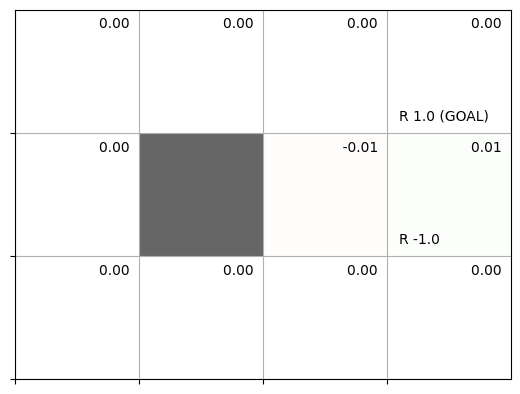

Ep[100]/St[30] state: (0, 2), action: 3:→, reward: 1.0


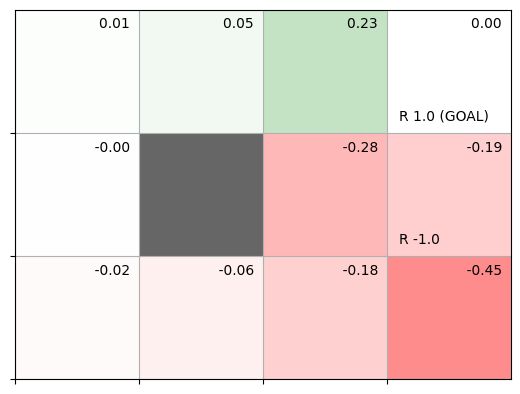

Ep[200]/St[26] state: (0, 2), action: 3:→, reward: 1.0


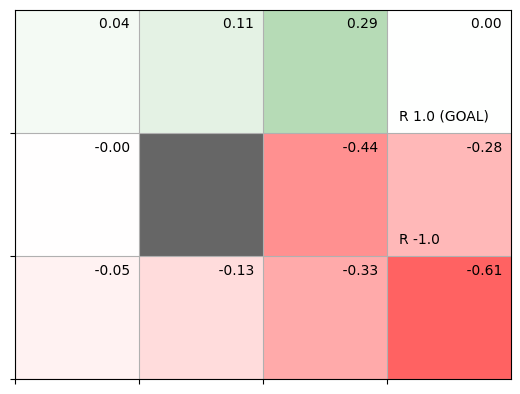

Ep[300]/St[11] state: (1, 3), action: 0:↓, reward: 1.0


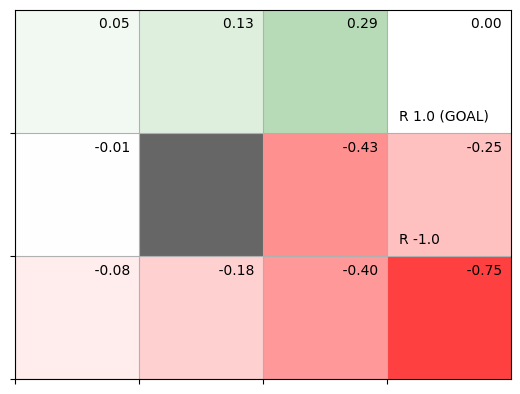

Ep[400]/St[27] state: (0, 2), action: 3:→, reward: 1.0


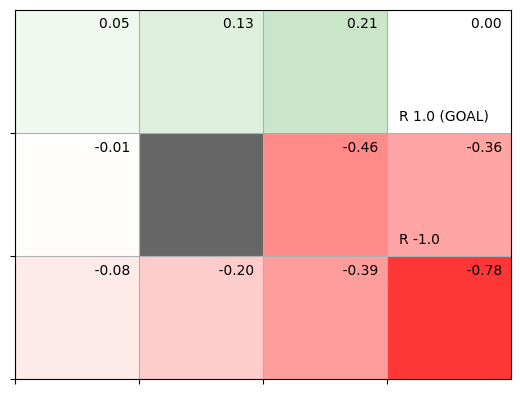

Ep[500]/St[14] state: (0, 2), action: 3:→, reward: 1.0


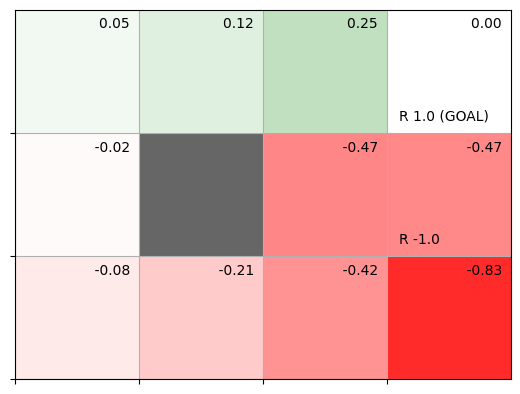

Ep[600]/St[66] state: (0, 2), action: 3:→, reward: 1.0


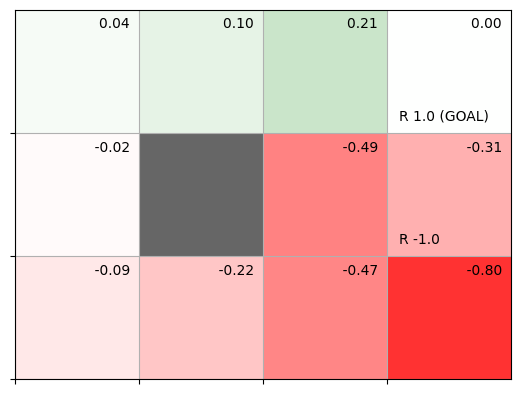

Ep[700]/St[79] state: (1, 3), action: 0:↓, reward: 1.0


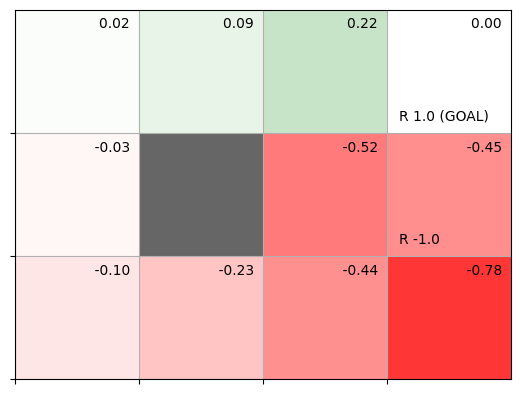

Ep[800]/St[9] state: (0, 2), action: 3:→, reward: 1.0


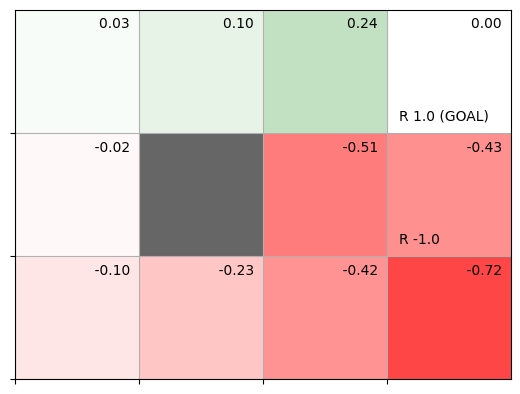

Ep[900]/St[21] state: (0, 2), action: 3:→, reward: 1.0


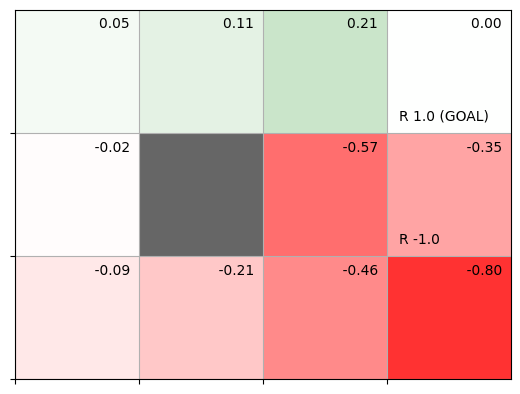

Result of eval V-map


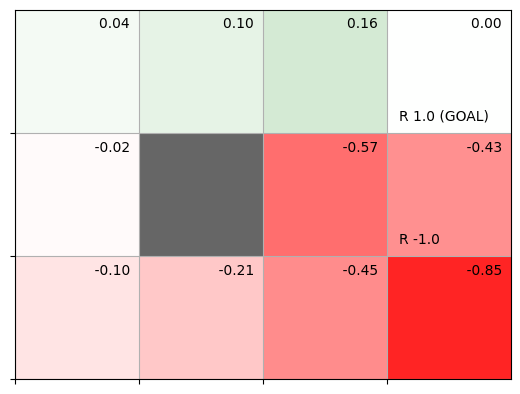

In [7]:
env = GridWorld()
agent = TdAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()
    step = 0

    # 1EPにおけるエージェントの行動と状態遷移
    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        # ここがMC法と異なる. 1状態進むごとに学習する
        agent.eval(state, reward, next_state, done)

        if done:
            break

        # 状態遷移(ここでは決定論的)
        state = next_state

        step += 1

    if episode % 100 == 0:
        print(f"Ep[{episode}]/St[{step}] state: {state}, action: {action}:{move(action)}, reward: {reward}")
        env.render_v(agent.V)

# TD法による方策評価の結果
print('Result of eval V-map') 
env.render_v(agent.V)

方策オン型: SARSA法による方策制御
+ 方策制御を行うには状態価値関数$V_{\pi}(s)$ではなく行動価値関数$Q_{\pi}(s,a)$を対象にしなければならない.
+ 方策の改善にはε-greedy法以外にもさまざまなものがある。
+ 状態価値関数$V_{\pi}(s)$を使って、方策改善を行うには、環境モデルが必要.
+ 行動価値関数$Q_{\pi}(s,a)$を直接使うと、方策改善で環境モデルが不要.

$$\mu(s) = argmax_{a}　Q_{\pi}(s,a)$$

行動価値関数を対象にしたTD法
$$Q'_{\pi}(S_{t},A_{t}) = Q_{\pi}(S_{t},A_{t}) + \alpha \{ R_{t} + \gamma Q_{\pi}(S_{t+1},A_{t+1}) - Q_{\pi}(S_{t},A_{t}) \}$$
+ ターゲット: $R_{t} + \gamma Q_{\pi}(S_{t+1},A_{t+1})$
+ 方策評価するだけなら, 状態価値関数Vだけわかれば良い、方策制御を行うには行動価値関数Qが必要

方策オン型の方策制御では、方策制御を完全にgreedy化できない. ε-greedy法などの準greedy法を使う
+ $(S_t,A_t,R_t,S_{t+1},A_{t+1})$ が得られた場合, 行動価値関数を対象にしたTD法で方策制御できる

$$
\pi'(a|S_t) = 
\begin{cases} 
  argmax_{a}Q_{\pi}(s,a), & (1-\epsilon)  \\
  ランダムな行動,   & \epsilon
\end{cases}
$$

In [8]:
# ε-greedy法
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state,action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    base_prob = epsilon / action_size
    action_probs = { action: base_prob for action in range(action_size) }
    # この時点でaction_probsは {0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon) # ε/4 + (1 - ε) = 1 - 3ε/4. sum = ε/4 + (1-3ε/4) + ε/4 + ε/4 = 1.0
    return action_probs

In [9]:
# 方策オン型の方策制御では、方策制御を完全にgreedy化できない. ここではε-greedy法を使う

from collections import deque

class SarsaAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {
            0: .25,
            1: .25,
            2: .25,
            3: .25,
        }

        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0) # 行動価値関数
        self.memory = deque(maxlen=2)   # TD1法ではmaxlen=2

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)
    
    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done)) # 1ステップ進んで経験する

        # TD1法
        if len(self.memory) < 2:
            return
        
        state, action, reward, done = self.memory[0]   # 現在のエージェントに関する情報 
        next_state, next_action, _, _ = self.memory[1] # エージェントが行動した後の情報

        # 次のQ関数
        next_q = 0 if done else self.Q[next_state, next_action]

        # TD法による更新
        target = reward + self.gamma * next_q # ターゲット
        self.Q[state, action] += self.alpha * (target - self.Q[state, action])

        # 方策改善
        self.pi[state] = greedy_probs(self.Q, state, self.epsilon)

    

TD法&SARSA法で3x4グリッドワールドにエージェントを行動させてみる

Ep[0]/St[584] state: (0, 2), action: 3:→, reward: 1.0


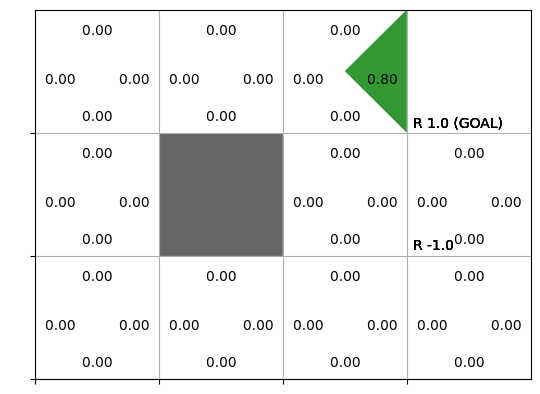

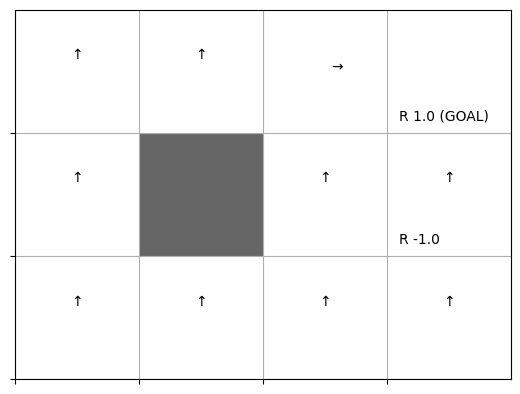

Ep[1000]/St[7] state: (0, 2), action: 3:→, reward: 1.0


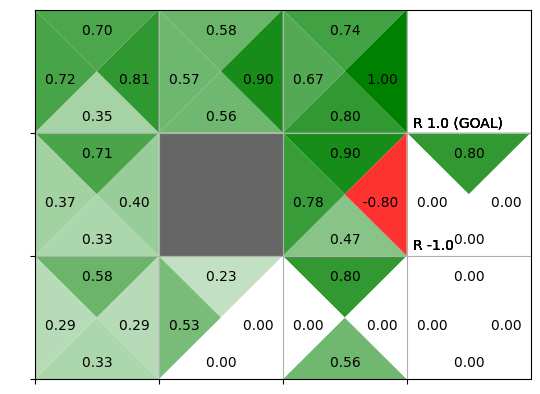

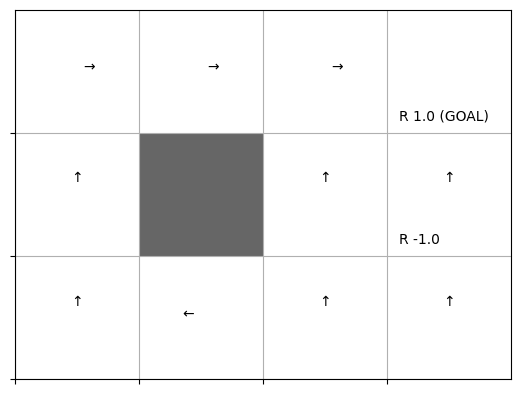

Ep[2000]/St[7] state: (0, 2), action: 3:→, reward: 1.0


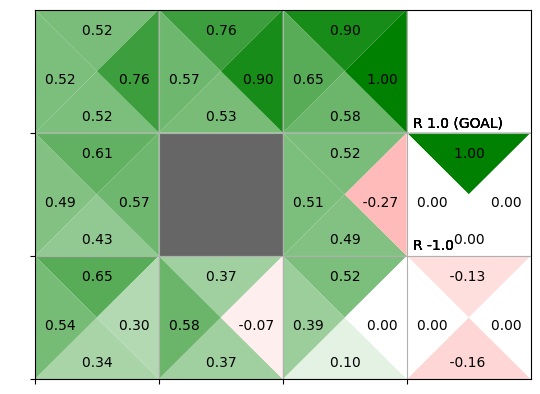

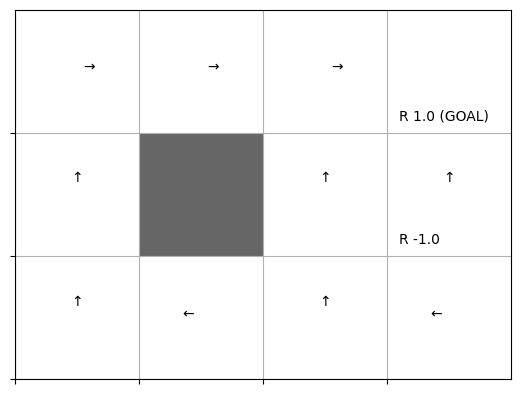

Ep[3000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


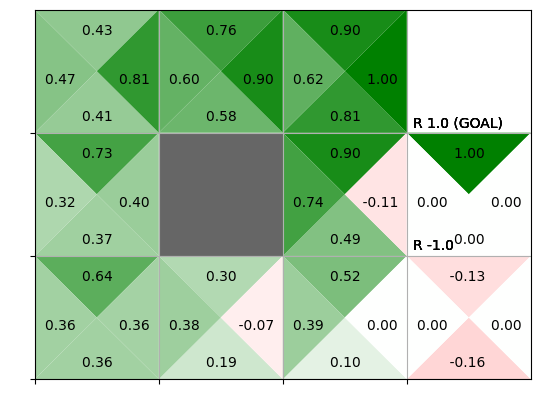

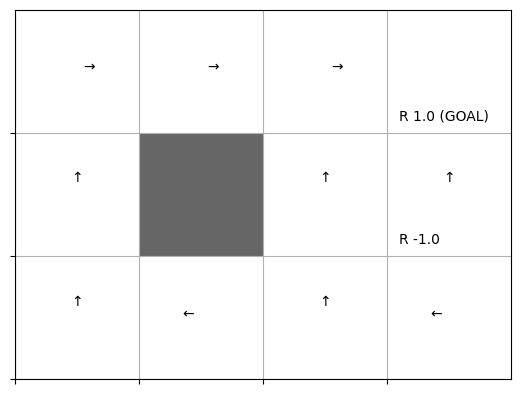

Ep[4000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


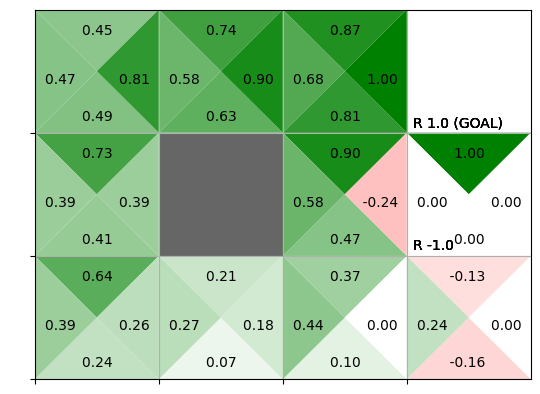

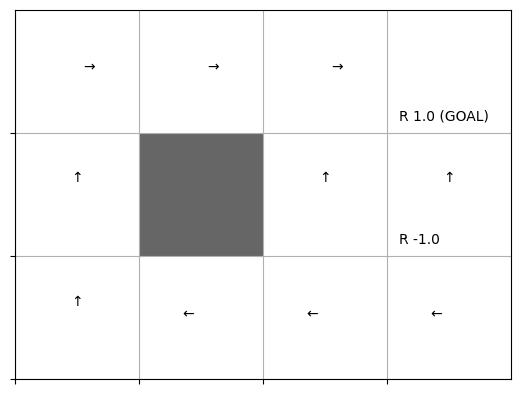

Ep[5000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


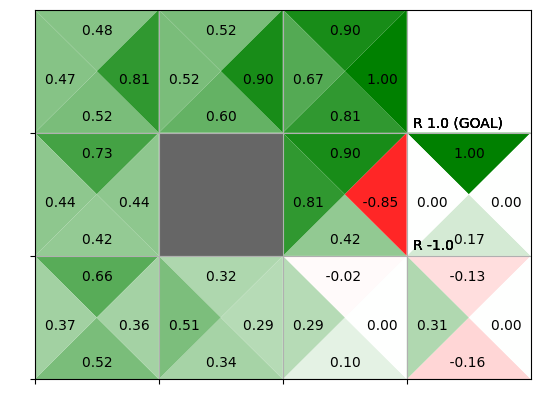

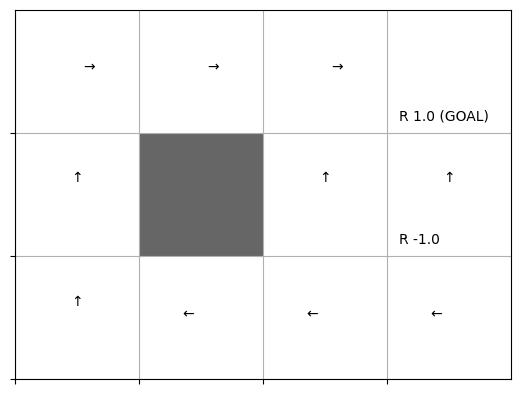

Ep[6000]/St[11] state: (0, 2), action: 3:→, reward: 1.0


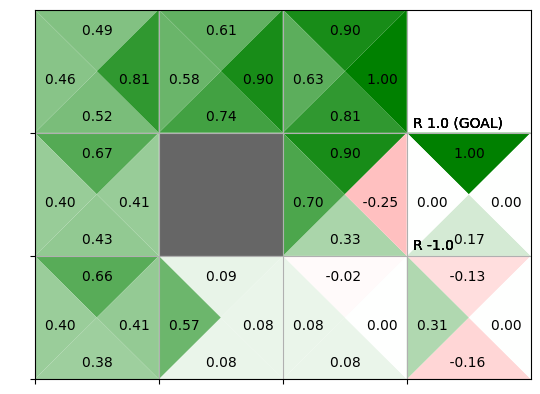

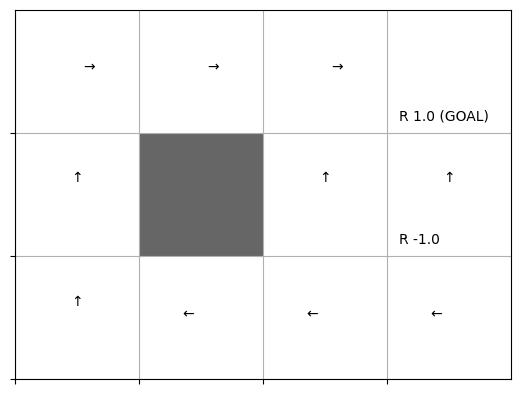

Ep[7000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


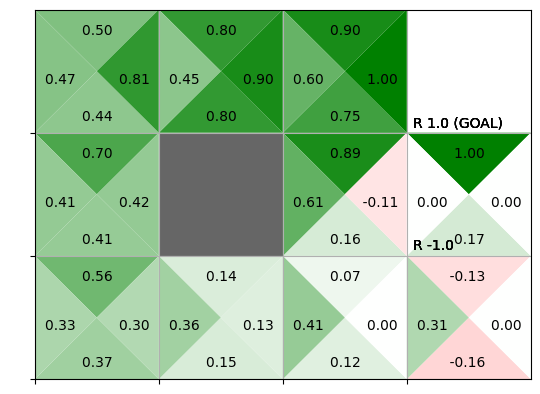

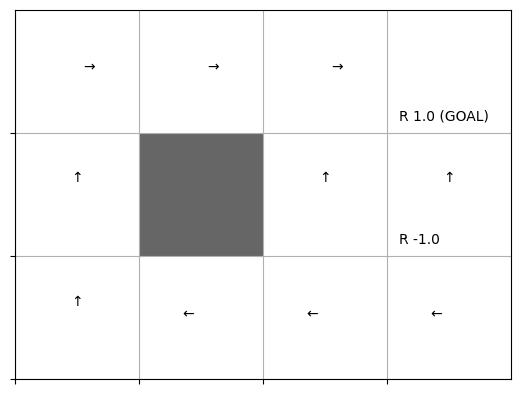

Ep[8000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


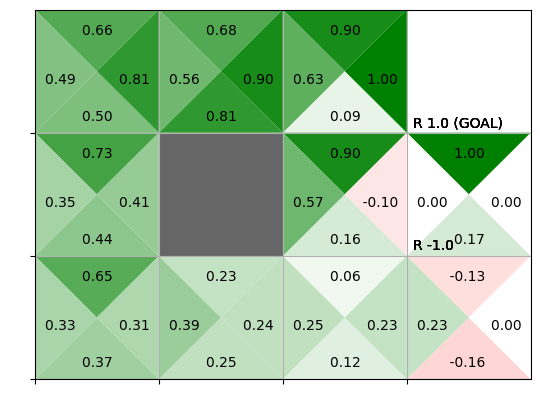

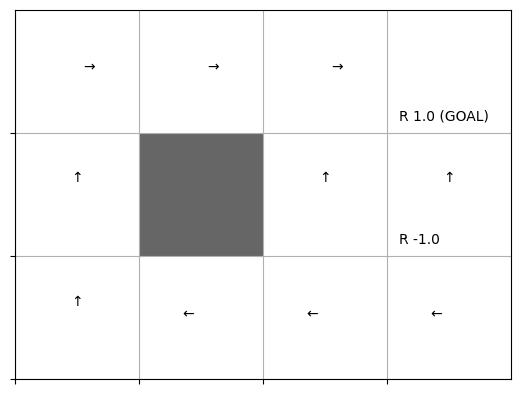

Ep[9000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


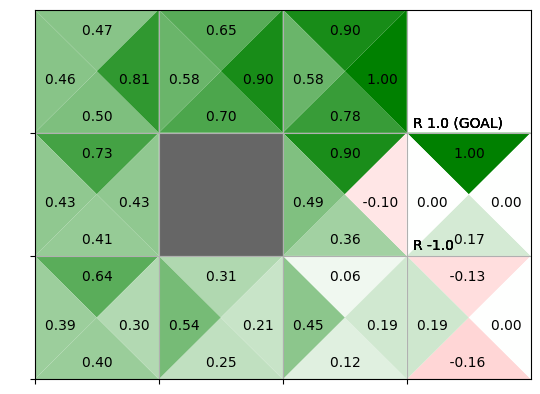

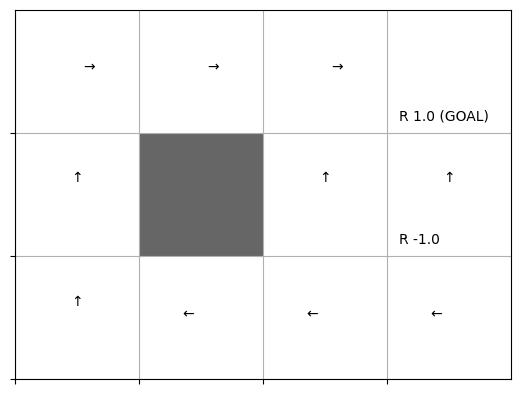

Result of eval Q-map


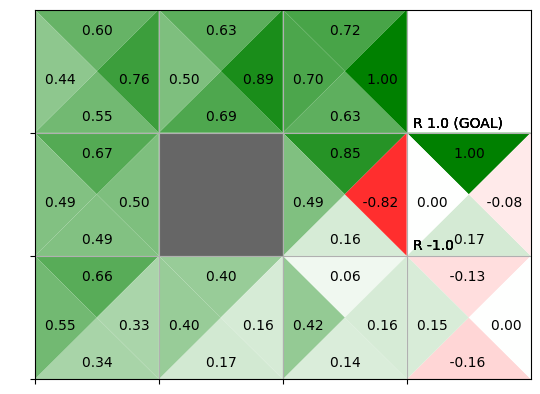

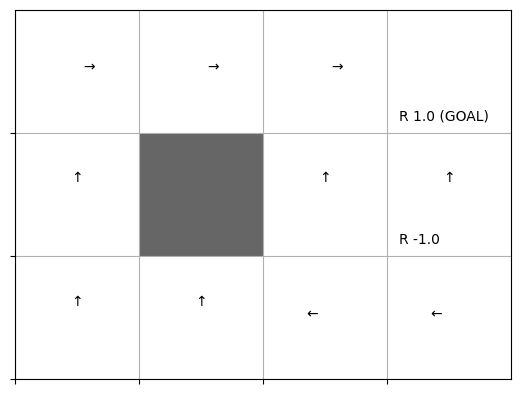

In [8]:
env = GridWorld()
agent = SarsaAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()
    step = 0

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done) # 毎回呼ぶ(DP法と同じ)

        if done:
            # ゴールに到達した時も呼ぶ (MC法と同じ)
            agent.update(next_state, None, None, None)
            break

        # 決定論的状態遷移
        state = next_state

        step += 1

    if episode % 1000 == 0:
        print(f"Ep[{episode}]/St[{step}] state: {state}, action: {action}:{move(action)}, reward: {reward}")
        env.render_q(agent.Q)

# TD法による方策評価の結果
print('Result of eval Q-map') 
env.render_q(agent.Q)

##### 方策オフ型のSARSA法
+ 方策オフ型: 自分が経験した以外の場所で得られた情報に基づいて自分の方策を更新すると取り組み
+ 挙動方策: エージェントが実際に行動を起こす際に使用する方策
+ ターゲット方策: 評価と改善の対象となる方策
+ 重点サンプリング: 同じ確率変数(状態s)に関する二つの確率分布(考え方)がある時、一方からサンプリングした情報に基づいてもう一方の期待値を更新する方法
+ 補足：考え方の類似度はカルバックライブラー距離 D(q||p)で示せると思う.

##### 重点サンプリング

$$E_{\pi}[x] = \sum x \pi(x)$$
$$sampling: x^{(i)} \sim \pi (i=1,2, \cdots n) $$
$$E_{\pi}[x] \simeq \frac{x^{(1)} + x^{(2)} + \cdots x^{(n)}}{n}$$

* 確率変数xが別の確率分布bからサンプリングされる場合に期待値はどのように近似できるか？
$$E_{\pi}[x] = \sum x \frac{\pi(x)}{b(x)} b(x) = E_{b}[x \frac{\pi(x)}{b(x)}]$$

* 確率分布$\pi$から確率分布$b$に変更した期待値で表せる
$$sampling: x^{(i)} \sim b(i=1,2, \cdots n) $$
$$\rho(x) = \frac{\pi(x)}{b(x)} = 単なる変換用重み$$
$$E_{\pi}[x] \simeq \frac{\rho(x^{(1)})x^{(1)} + \rho(x^{(2)})x^{(2)} + \cdots \rho(x^{(n)})x^{(n)}}{n}$$

In [10]:
####################################
# 重点サンプリングによる期待値の近似(例) #
####################################
import numpy as np
x = np.array([1,2,3]) # 確率変数x
pi = np.array([0.1,0.1,0.8]) # 確率分布

# 本来の期待値
e = np.sum(x * pi)
print(f'真なる期待値 E_pi[x]: {e:.2f}')


# モンテカルロ法(大数の法則)による期待値を平均で近似
n = 1000
samples = []
for _ in range(n):
    s = np.random.choice(x, p=pi)
    samples.append(s)

mc_mean = np.mean(samples)
mc_var = np.var(samples)
print(f'MC: mean {mc_mean:.2f}, var {mc_var:.2f}')


# 重点サンプリングMC
# 異なる確率分布b(x)
b = np.array([1/3,1/3,1/3])
n = 1000
samples = []
for _ in range(n):
    idx = np.arange(len(b)) # インデックスを経由するのがミソ
    i = np.random.choice(idx, p=b) # bを使ってサンプリング
    s = x[i] # 確率分布πからのサンプリング
    rho = pi[i] / b[i] # 重み
    samples.append(rho * s)

bmc_mean = np.mean(samples)
bmc_var = np.var(samples)
print(f'重点サンプリングMC: mean {bmc_mean:.2f}, var {bmc_var:.2f}') # 分散は大きくなる

真なる期待値 E_pi[x]: 2.70
MC: mean 2.69, var 0.42
重点サンプリングMC: mean 2.78, var 10.35


##### 重点サンプリングによる方策オフ型のSARSAの実装

$$sampling : A_{t+1} \sim \pi$$
$$Q'_{\pi}(S_{t},A_{t}) = Q_{\pi}(S_{t},A_{t}) + \alpha \{ R_{t} + \gamma Q_{\pi}(S_{t+1},A_{t+1}) - Q_{\pi}(S_{t},A_{t}) \}$$

$$sampling : A_{t+1} \sim b$$
$$Q'_{\pi}(S_{t},A_{t}) = Q_{\pi}(S_{t},A_{t}) + \alpha \{ \rho (R_{t} + \gamma Q_{\pi}(S_{t+1},A_{t+1})) - Q_{\pi}(S_{t},A_{t}) \}$$

$$\rho = \frac{\pi(A_{t+1}|S_{t+1})}{b(A_{t+1}|S_{t+1})}$$

+ 確率分布$\pi$と$b$から同じ数値を取り出す方法は同じインデックスを使う

In [16]:
random_actions = {
            0: .05, # ↑
            1: .15, # ↓
            2: .30, # ←
            3: .50, # →
        }
pi = defaultdict(lambda: random_actions)
b = defaultdict(lambda: random_actions)
Q = defaultdict(lambda: 0)
print(pi[0])
print(pi[0][1])

{0: 0.05, 1: 0.15, 2: 0.3, 3: 0.5}
0.15


In [18]:
# 方策オフ型のSARSA法
# TDターゲット: rho * (reward + gamma * nextQ)

class SarsaOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_sizee = 4

        random_actions = {
            0: .25, # ↑
            1: .25, # ↓
            2: .25, # ←
            3: .25, # →
        }
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.b[state] # 1. 挙動方策から取得
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)
    
    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return
        
        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        if done:
            # ゴール
            next_q = 0
            rho = 1 # 重点サンプリングの補正重みは1. つまり 確率分布: pi=b
        else:
            next_q = self.Q[next_state, next_action]
            rho = self.pi[next_state][next_action] / self.b[next_state][next_action] # 補正値を計算

        # 重点サンプリングを用いた方策オフ型SARSA法のTDターゲット
        target = rho * (reward + self.gamma * next_q)
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        # 方策改善(挙動方策: ε-greedy法, ターゲット方策: greedy法)
        self.pi[state] = greedy_probs(self.Q, state, 0) # greedy
        self.b[state] = greedy_probs(self.Q, state, self.epsilon) # ε-greedy


Ep[0]/St[321] state: (0, 2), action: 3:→, reward: 1.0


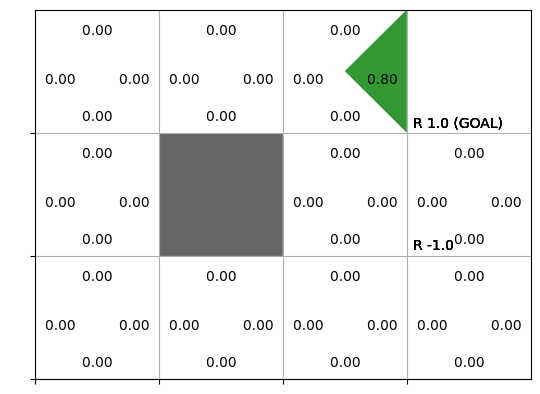

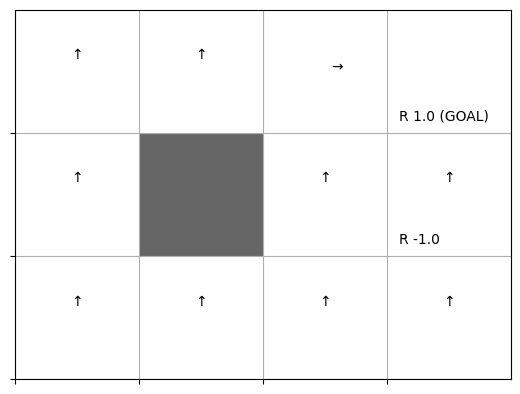

Ep[1000]/St[47] state: (0, 2), action: 3:→, reward: 1.0


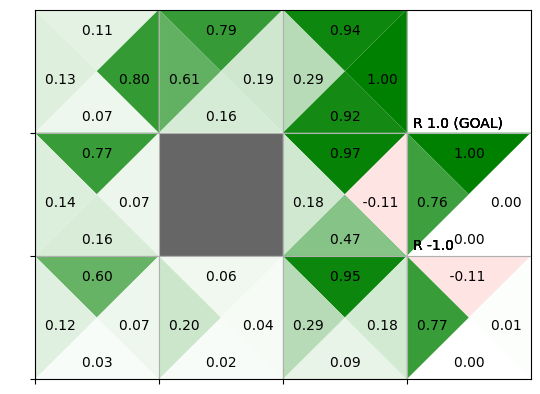

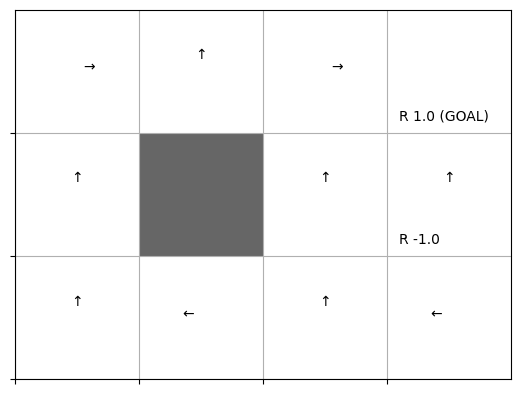

Ep[2000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


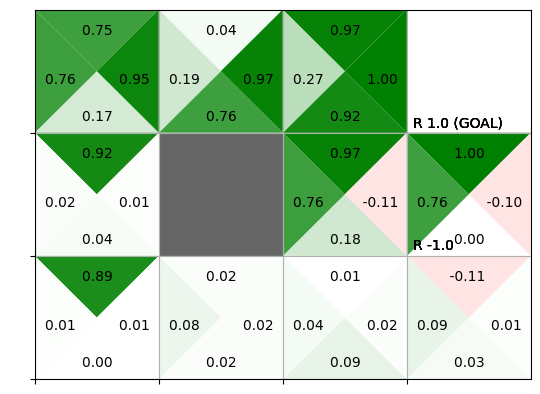

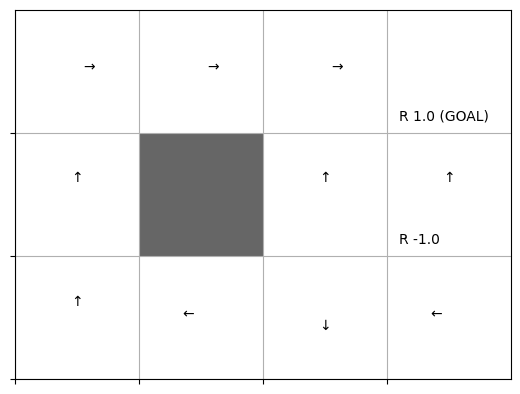

Ep[3000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


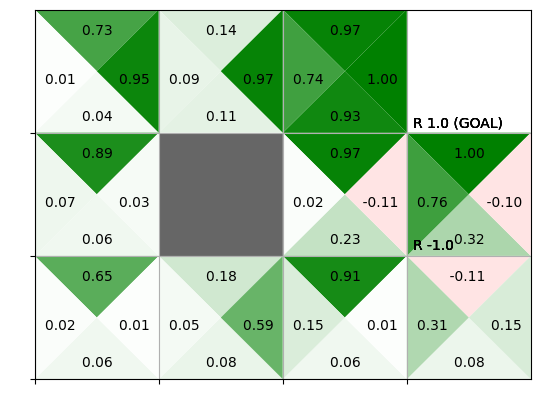

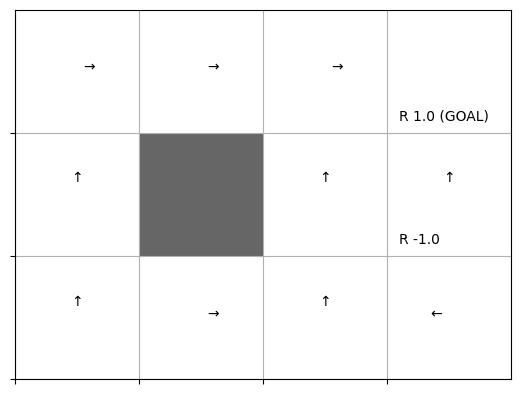

Ep[4000]/St[35] state: (0, 2), action: 3:→, reward: 1.0


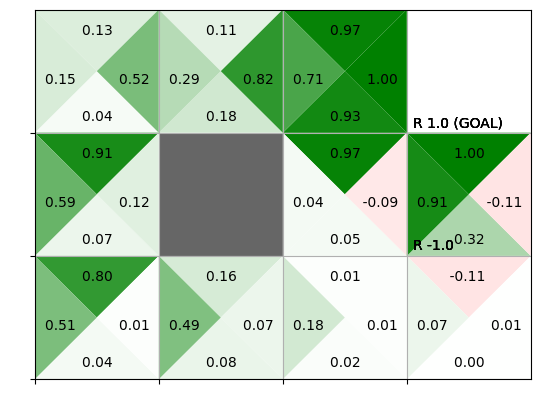

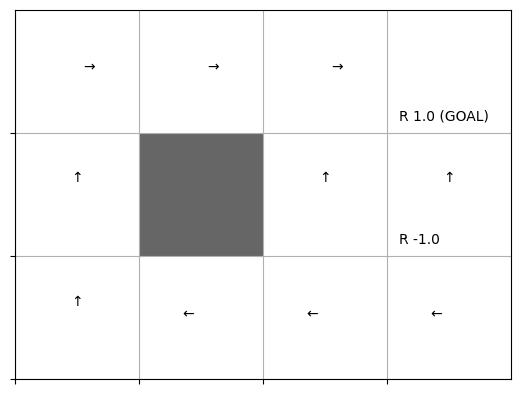

Ep[5000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


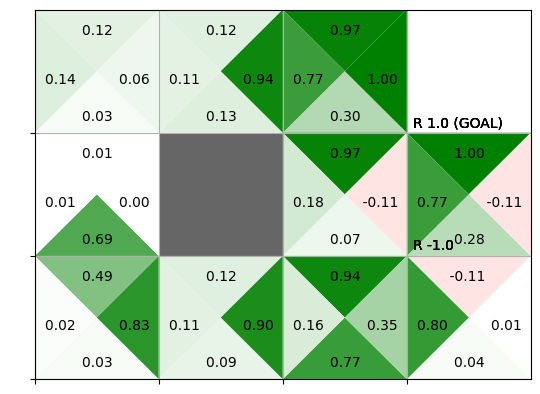

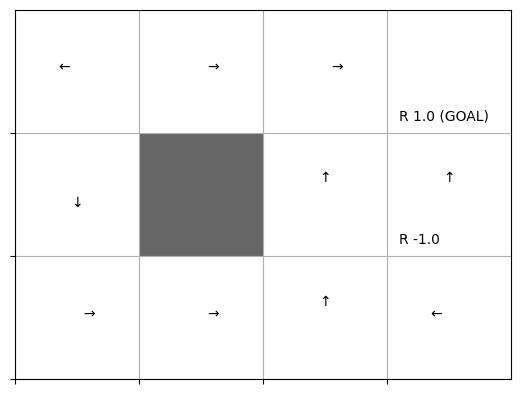

Ep[6000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


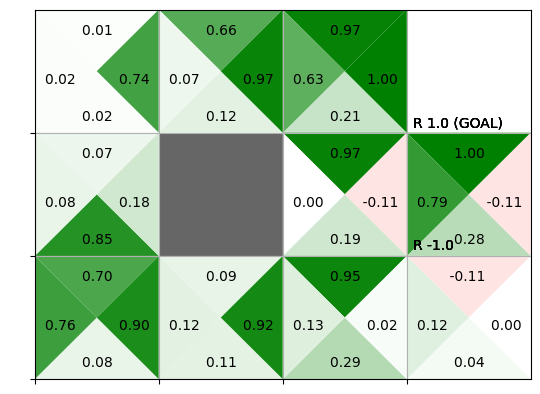

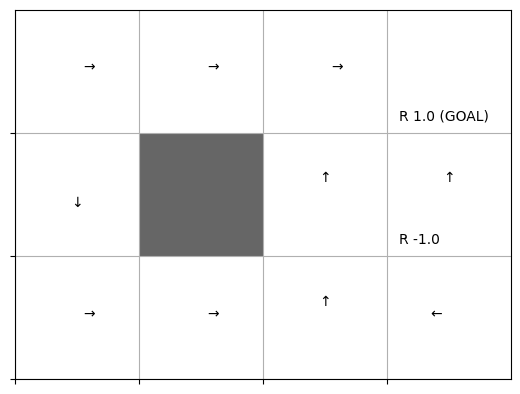

Ep[7000]/St[10] state: (0, 2), action: 3:→, reward: 1.0


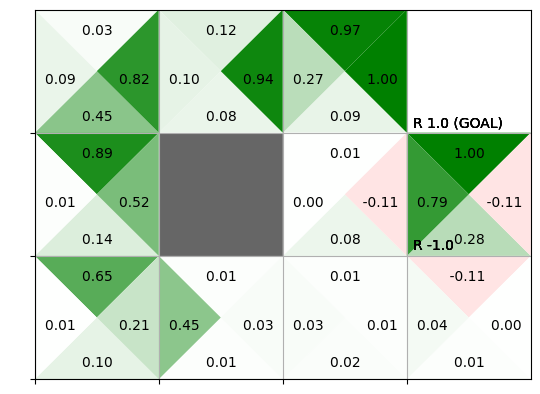

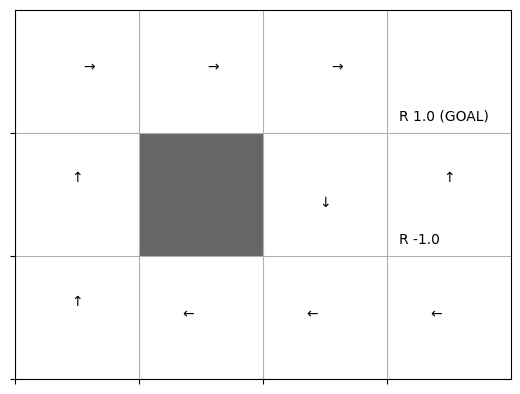

Ep[8000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


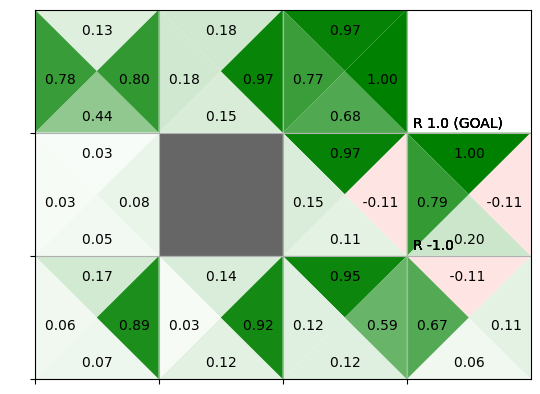

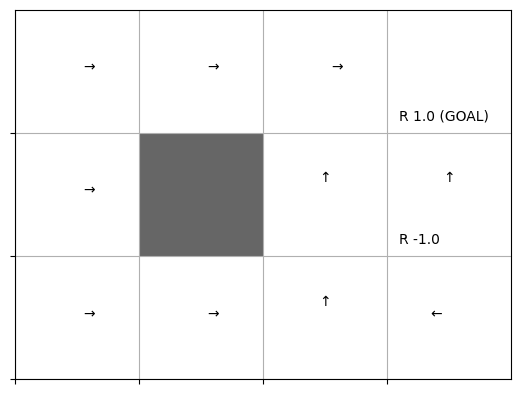

Ep[9000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


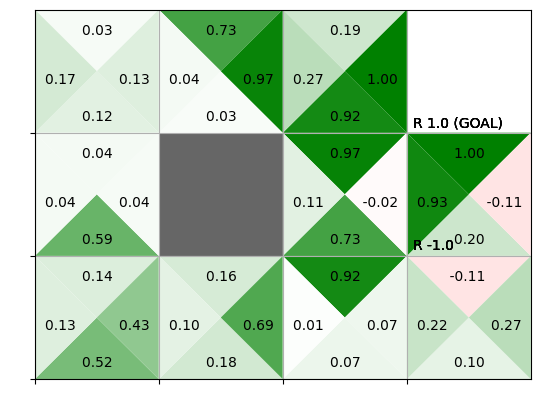

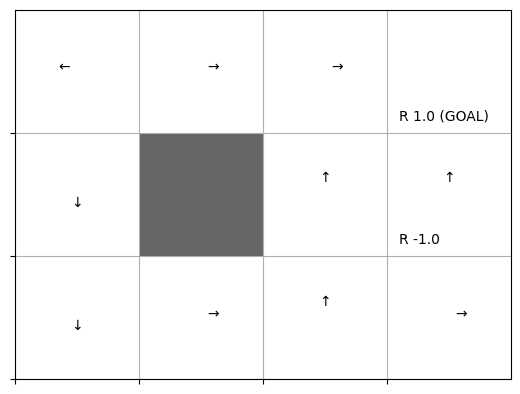

Result of eval Q-map (OffPolicy SARSA)


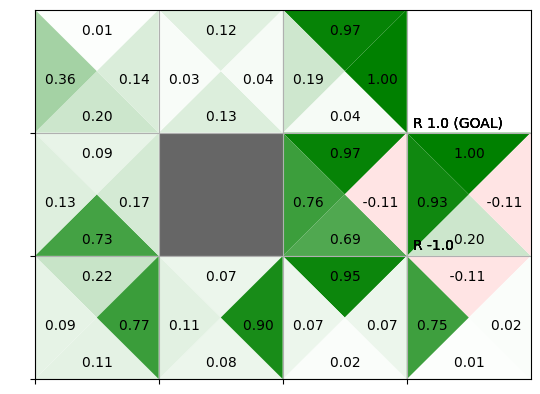

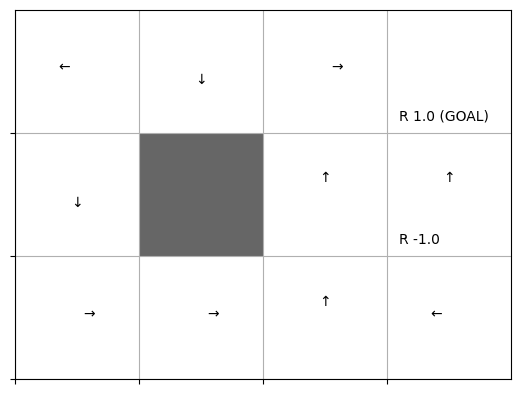

In [20]:
env = GridWorld()
agent = SarsaOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()
    step = 0

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done) # 毎回呼ぶ(DP法と同じ)

        if done:
            # ゴールに到達した時も呼ぶ (MC法と同じ)
            agent.update(next_state, None, None, None)
            break

        # 決定論的状態遷移
        state = next_state

        step += 1

    if episode % 1000 == 0:
        print(f"Ep[{episode}]/St[{step}] state: {state}, action: {action}:{move(action)}, reward: {reward}")
        env.render_q(agent.Q)

# TD法による方策評価の結果
print('Result of eval Q-map (OffPolicy SARSA)') 
env.render_q(agent.Q)

#### Q学習
+ TD法
+ 方策オフ型
+ 重点サンプリングを使わない

重点サンプリングは, 結果が不安定になりやすい。特に2つの方策の確率分布が異なるほど、補正重み$\rho$も多く変動する。

+ ベルマン方程式 → SARSA
+ ベルマン最適方程式 → Q学習

##### ベルマン方程式とSARSA
+ Q関数を$q_{\pi}(s,a)$としたとき
$$q_{\pi}(s,a) = \sum_{s'} p(s'|s,a) \{ r(s,a,s') + \gamma \sum_{a'} \pi(a'|s') q_{\pi}(s'|a') \}$$
+ 更新式
$$Q'(S_{t},A_{t}) = Q(S_{t},A_{t}) + \alpha \{ R_{t} + \gamma Q_{\pi}(S_{t+1},A_{t+1}) - Q_{\pi}(S_{t},A_{t}) \}$$
+ SARSAでは、次の状態 $S_{t+1}$ は, $p(s'|s,a)$ に基づきサンプリングする. そして、次の行動$A_{t+1}$は, 方策$\pi(a|s)$に基づきサンプリングする.
+ TDターゲットは$R_{t} + \gamma Q_{\pi}(S_{t+1},A_{t+1})$

##### ベルマン最適方程式とQ学習
+ ベルマン最適方程式に対応するサンプリング版がQ学習
+ 最適行動価値関数 $q_{*}(s,a)$
$$q_{*}(s,a) = \sum_{s'} p(s'|s,a) \{ r(s,a,s') + \gamma * max_{a'} q_{*}(s',a') \}$$
+ TDターゲットは$R_{t} + \gamma * max_{a} Q(S_{t+1},a)$
+ 更新式
$$Q'(S_{t},A_{t}) = Q(S_{t},A_{t}) + \alpha \{ R_{t} + \gamma max_{a} Q(S_{t+1},a) - Q(S_{t},A_{t}) \}$$
+ この更新式を繰り返すと最適方策に近づく
+ サンプリングはしない
+ 挙動方策bには「探索」させる(ε-greedy法)
+ ターゲット方策piには「活用」させる(greedy法)

In [21]:
# Q学習の実装

class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {
            0: .25, # ↑
            1: .25, # ↓
            2: .25, # ←
            3: .25, # →
        }
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.b[state] # 1. 挙動方策から取得
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)
    
    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            # 次の行動A_t+1の中で最もQが大きな値を使う
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs) # 最適行動価値関数を使う

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += self.alpha * (target - self.Q[state, action])

        # ターゲット方策
        self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)

Ep[0]/St[364] state: (0, 2), action: 3:→, reward: 1.0


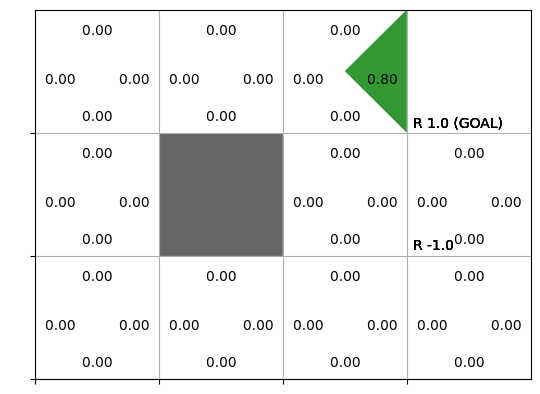

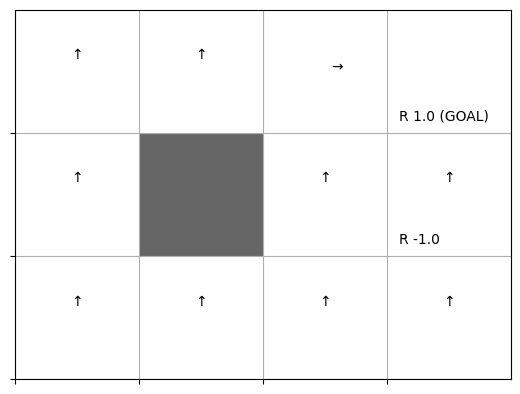

Ep[1000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


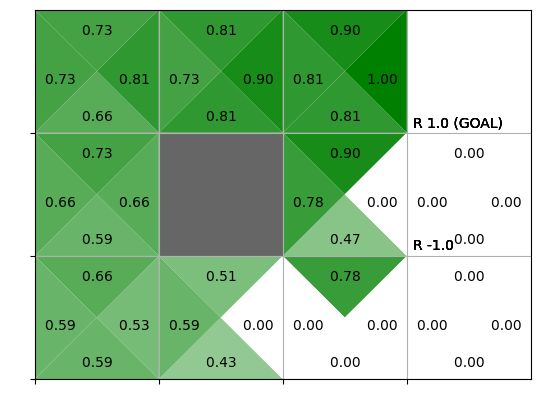

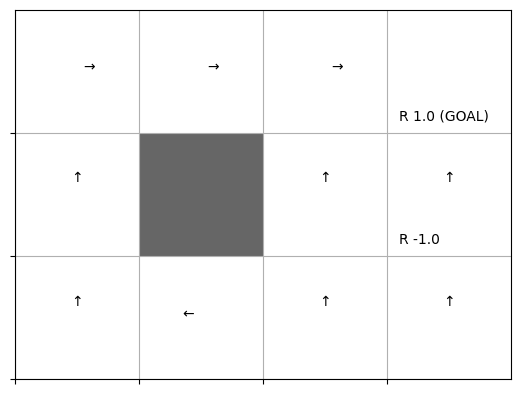

Ep[2000]/St[7] state: (0, 2), action: 3:→, reward: 1.0


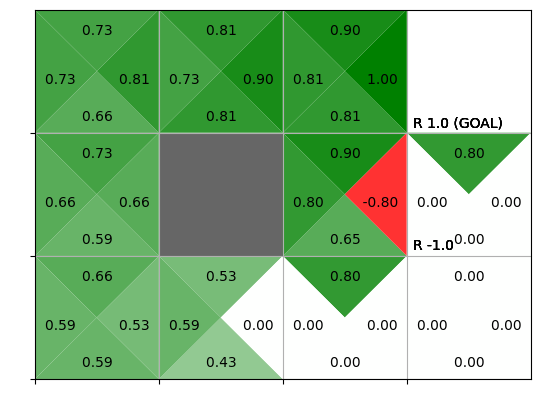

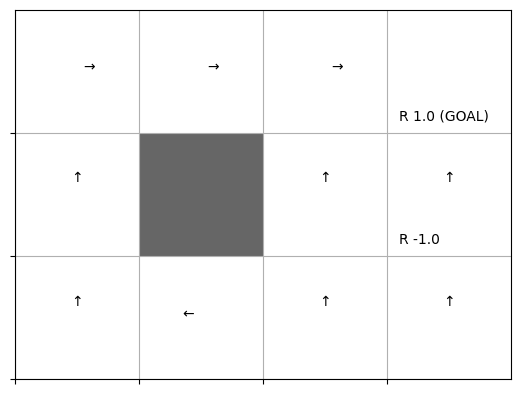

Ep[3000]/St[5] state: (0, 2), action: 3:→, reward: 1.0


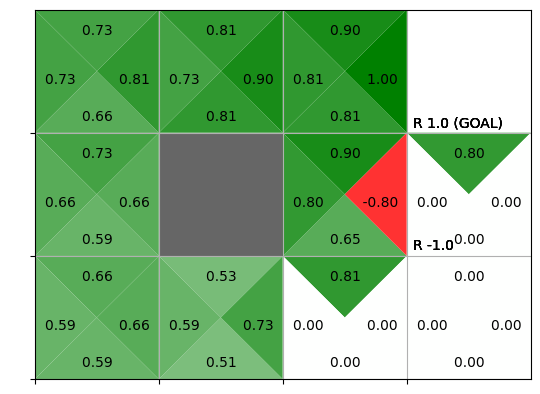

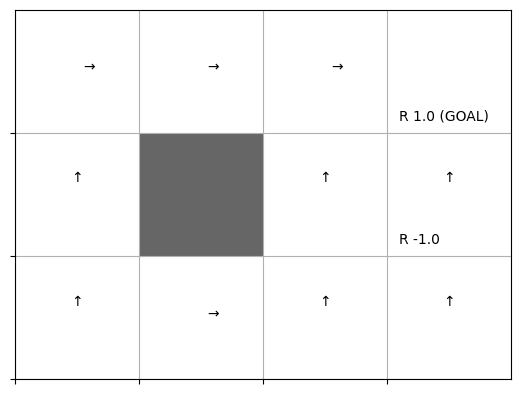

Ep[4000]/St[5] state: (0, 2), action: 3:→, reward: 1.0


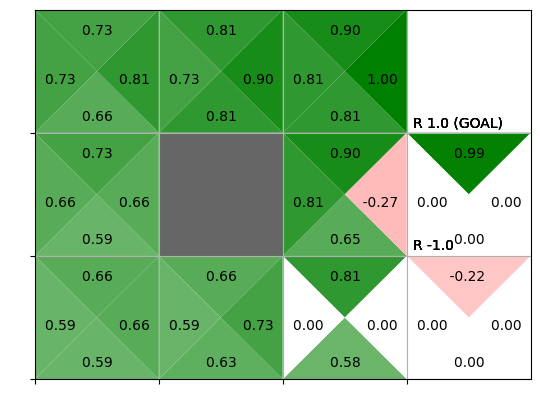

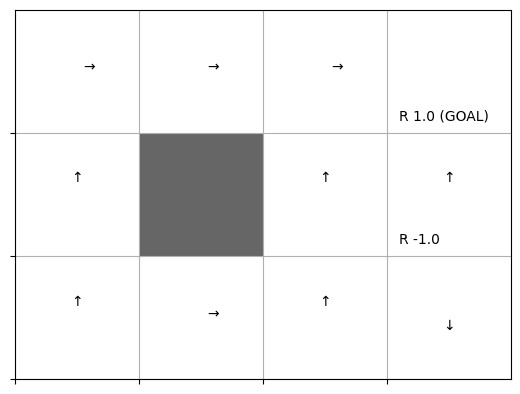

Ep[5000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


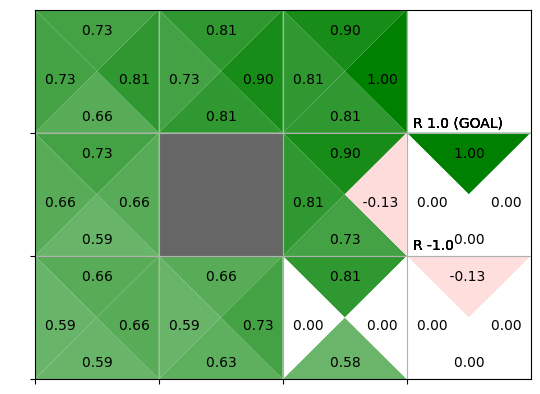

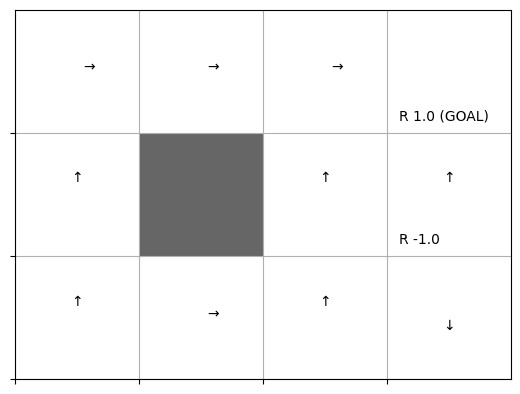

Ep[6000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


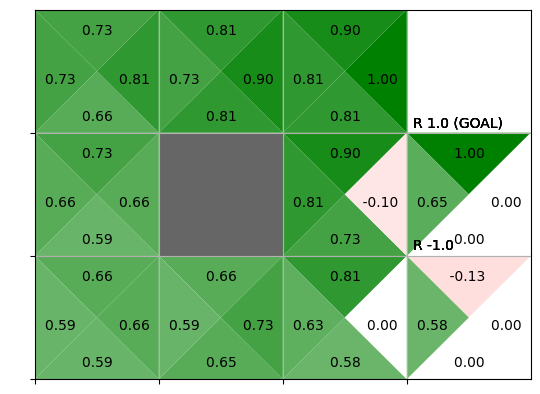

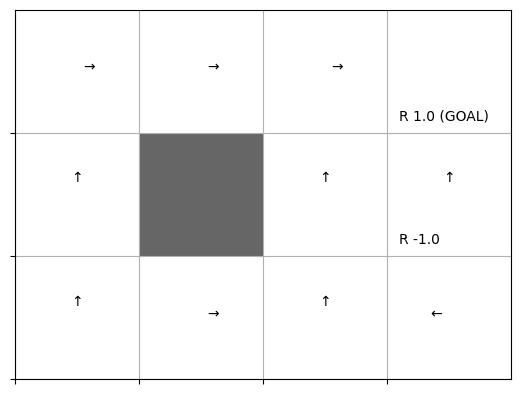

Ep[7000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


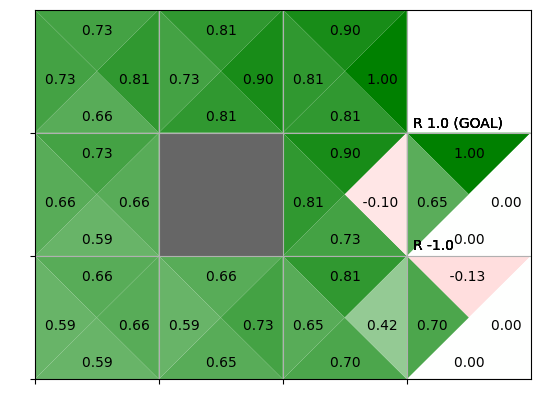

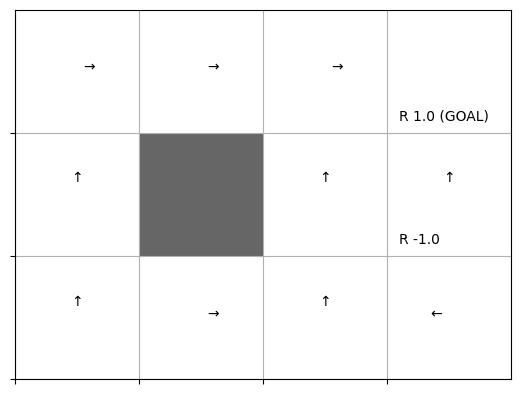

Ep[8000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


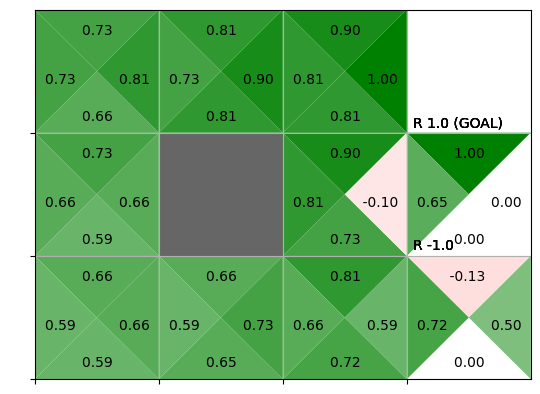

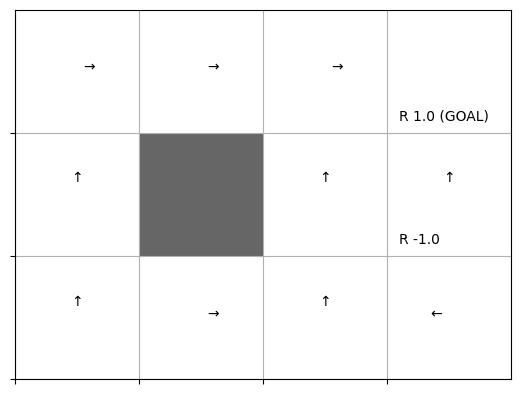

Ep[9000]/St[8] state: (0, 2), action: 3:→, reward: 1.0


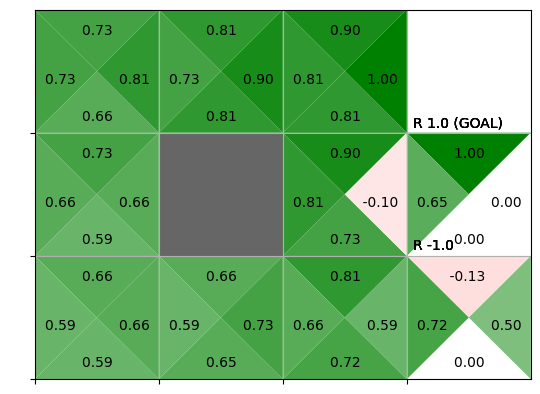

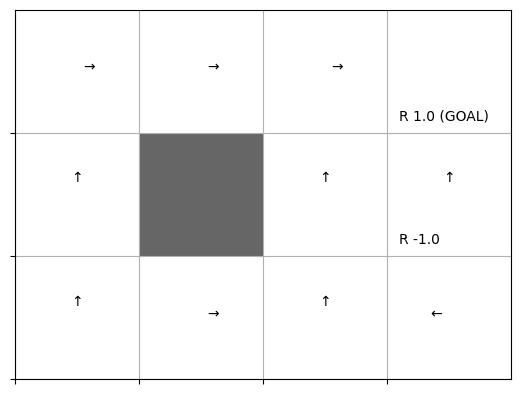

Result of eval Q-map (Q-Learning)


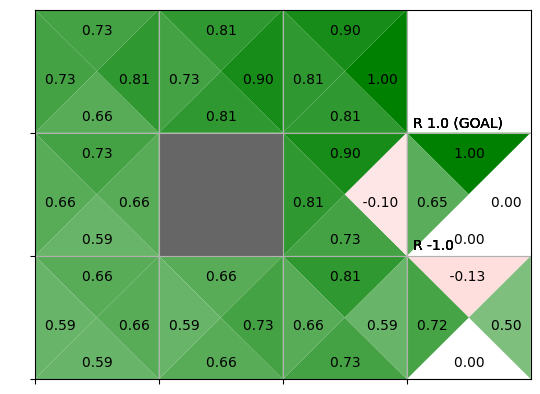

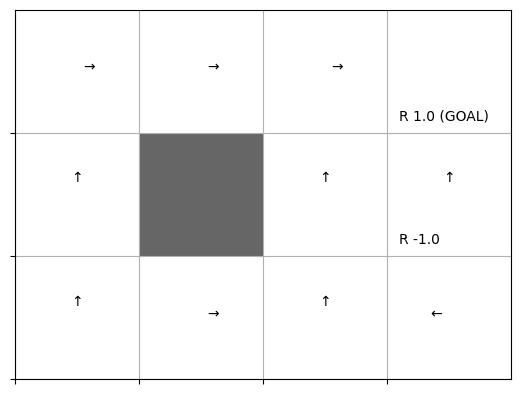

In [25]:
env = GridWorld()
agent = QLearningAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    step = 0

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done) # 毎回呼ぶ(DP法と同じ)

        if done:
            break

        # 決定論的状態遷移
        state = next_state

        step += 1

    if episode % 1000 == 0:
        print(f"Ep[{episode}]/St[{step}] state: {state}, action: {action}:{move(action)}, reward: {reward}")
        env.render_q(agent.Q)

# TD法による方策評価の結果
print('Result of eval Q-map (Q-Learning)') 
env.render_q(agent.Q)

#### 分布モデルとサンプルモデル
+ 確率的な振る舞いを実現する方法は2種類.

##### サンプルモデル版のQ学習

In [27]:
# 分布モデルのQ学習

class QLearningAgent_:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {
            0: .25, # ↑
            1: .25, # ↓
            2: .25, # ←
            3: .25, # →
        }
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)
    
    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs) # max Q
        
        target = reward + self.gamma * next_q_max
        self.Q[state, action] += self.alpha * (target - self.Q[state, action])

        
        # 方策改善(挙動方策: ε-greedy法, ターゲット方策: greedy法)
        self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)
        

In [ ]:
# サンプリングモデル版Q学習(ターゲット方策はまだある)

class QLearningAgent__:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {
            0: .25, # ↑
            1: .25, # ↓
            2: .25, # ←
            3: .25, # →
        }

        # self.pi = defaultdict(lambda: random_actions) # ターゲット方策は使わない
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        # このタイミングでε-greedy化
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)

        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)
    
    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs) # 最適行動価値関数

        target = self.gamma * next_q_max + reward
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

In [29]:
# Q学習のサンプリングモデル版(ターゲット方策は必要な時に自在に作れる)

class QLearningAgent___:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {
            0: .25, # ↑
            1: .25, # ↓
            2: .25, # ←
            3: .25, # →
        }

        # self.pi = defaultdict(lambda: random_actions) # ターゲット方策は使わない
        # self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        # 直接ここでε-greedy法を行う
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            qs = [self.Q[state, a] for a in range(self.action_size)]
            return np.argmax(qs)
        
    def update(self, state, aciton, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)] # S_t+1, A_t+1における行動価値関数のリスト
            next_q_max = max(next_qs)# 最適行動価値関数

        target = self.gamma * next_q_max + reward
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha


Ep[0]/St[16] state: (0, 2), action: 3:→, reward: 1.0


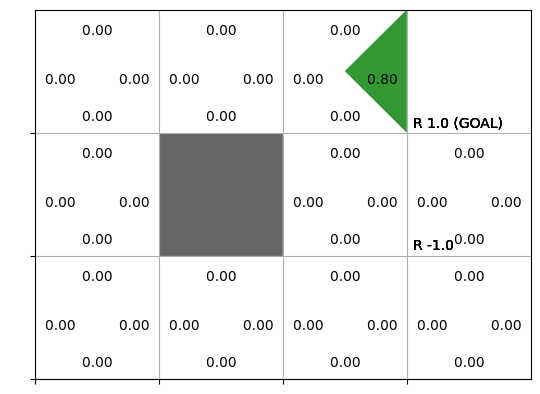

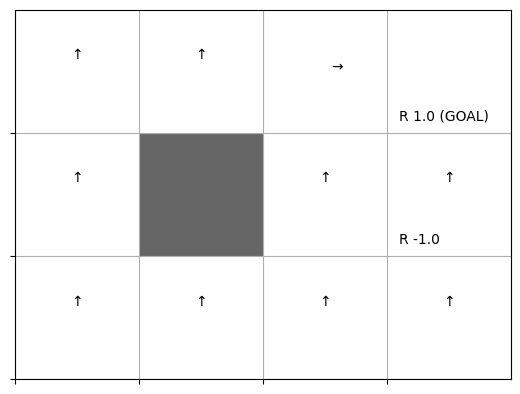

Ep[1000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


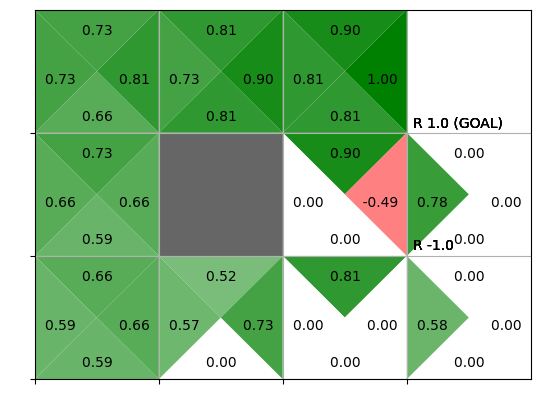

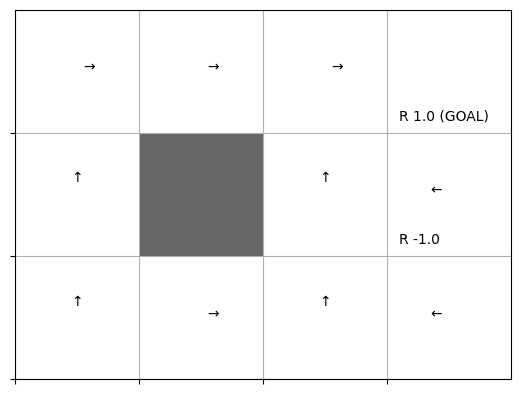

Ep[2000]/St[9] state: (0, 2), action: 3:→, reward: 1.0


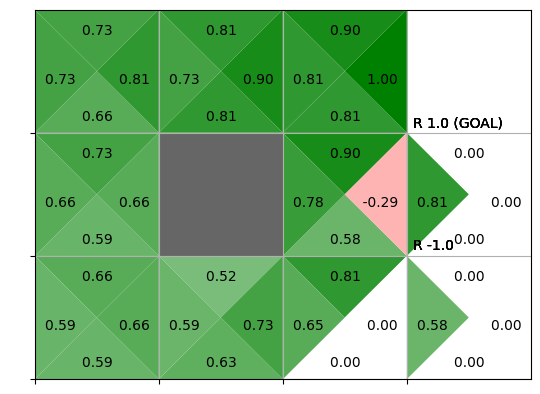

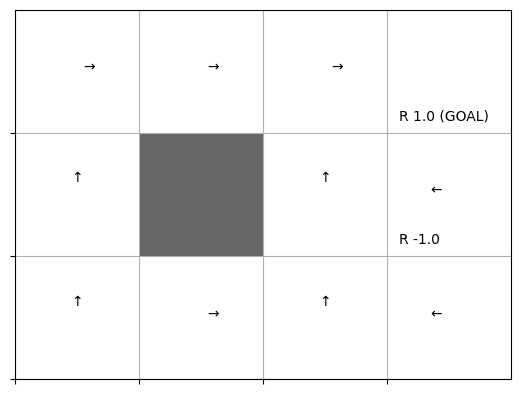

Ep[3000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


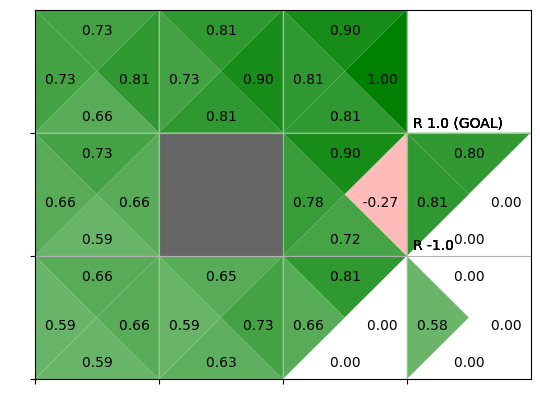

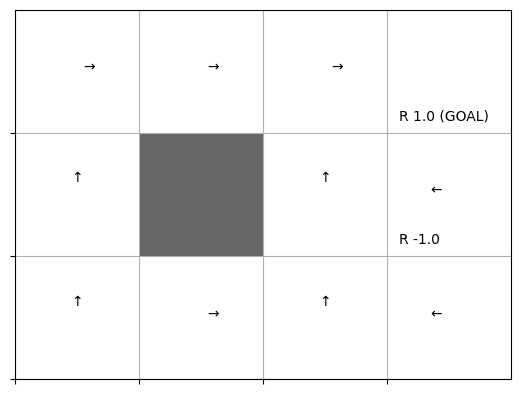

Ep[4000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


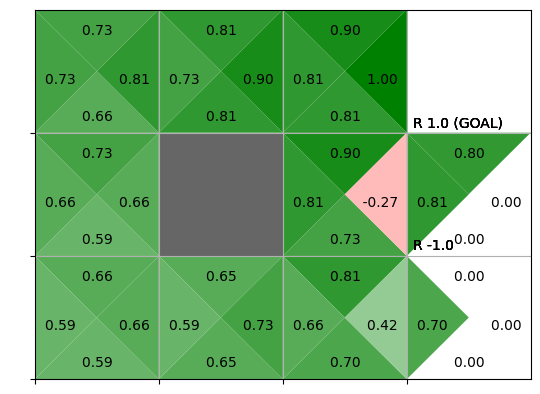

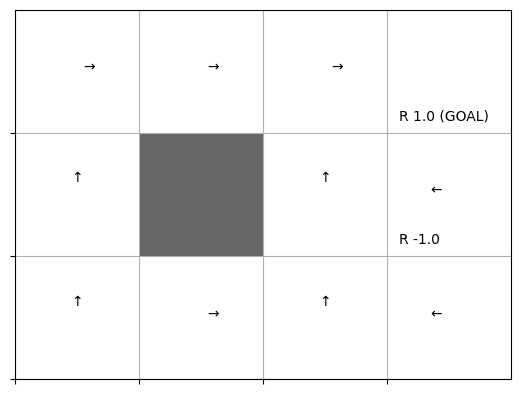

Ep[5000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


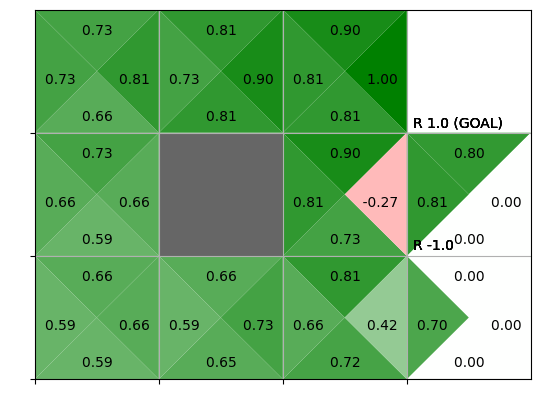

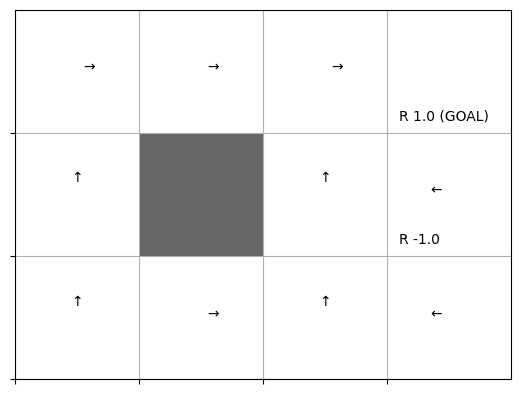

Ep[6000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


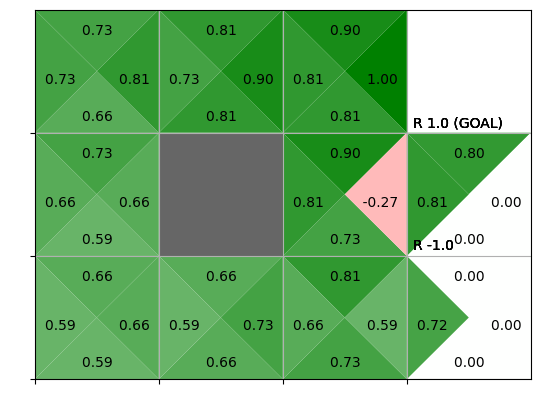

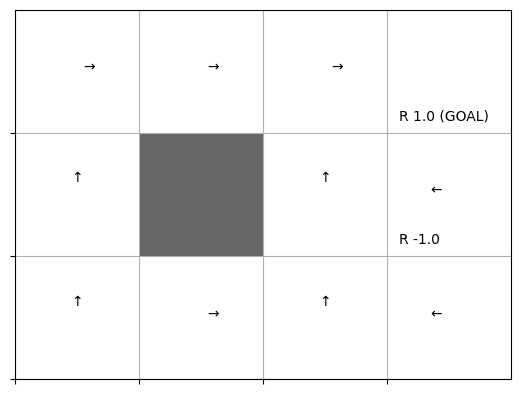

Ep[7000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


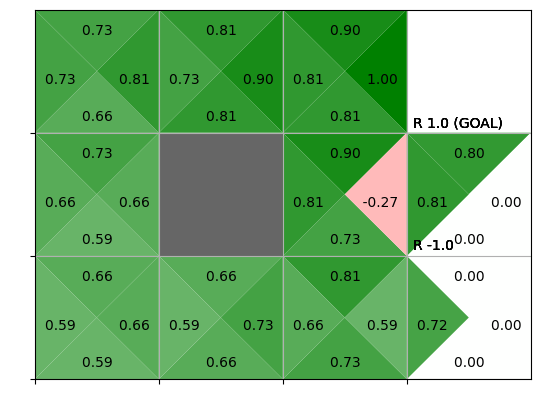

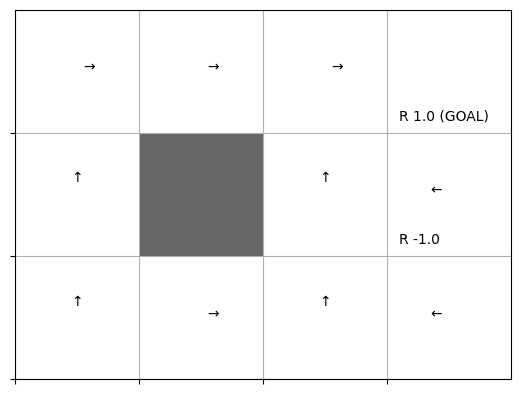

Ep[8000]/St[5] state: (0, 2), action: 3:→, reward: 1.0


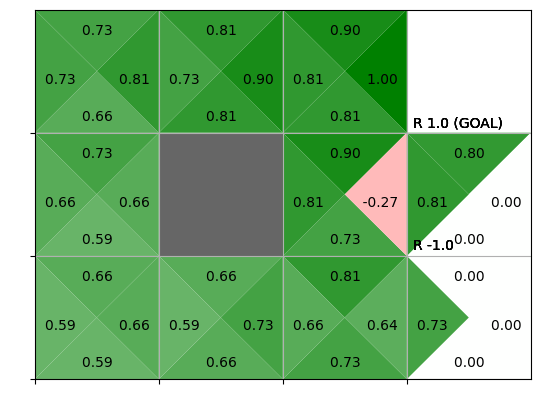

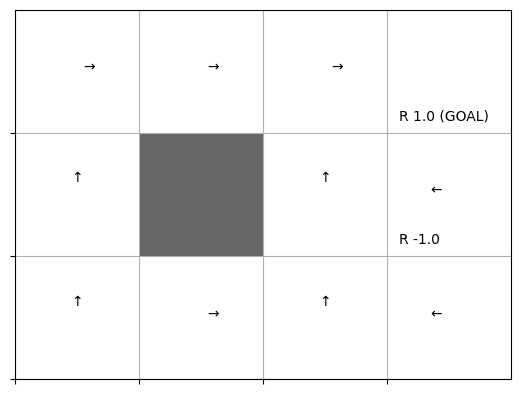

Ep[9000]/St[7] state: (0, 2), action: 3:→, reward: 1.0


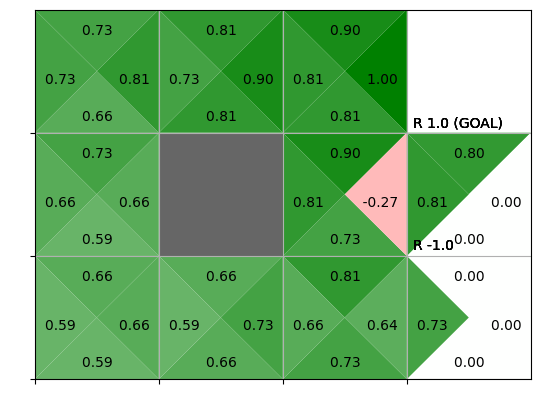

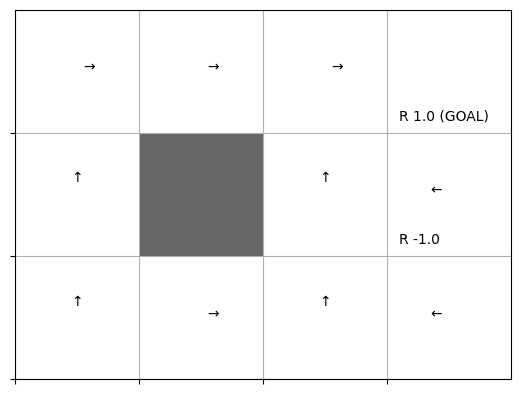

Result of eval Q-map (Q-Learning with Sampling model)


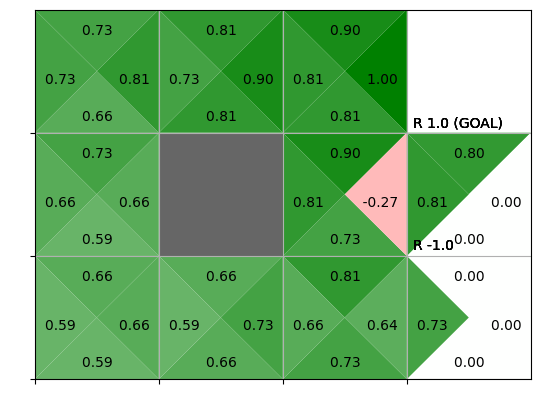

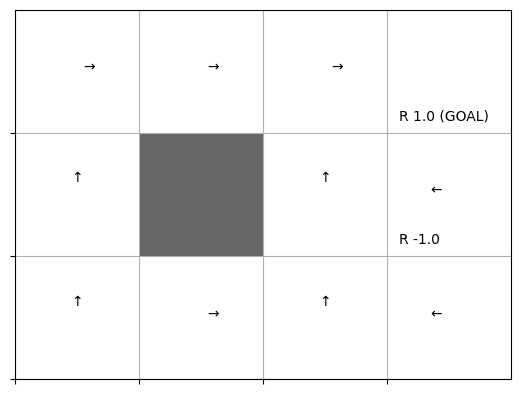

In [30]:
env = GridWorld()
agent = QLearningAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    step = 0

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done) # 毎回呼ぶ(DP法と同じ)

        if done:
            break

        # 決定論的状態遷移
        state = next_state

        step += 1

    if episode % 1000 == 0:
        print(f"Ep[{episode}]/St[{step}] state: {state}, action: {action}:{move(action)}, reward: {reward}")
        env.render_q(agent.Q)

# TD法による方策評価の結果
print('Result of eval Q-map (Q-Learning with Sampling model)') 
env.render_q(agent.Q)